In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
df= pd.read_csv("Country-data.csv")

In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [6]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [7]:
#removing extra space to avoid errors
df.columns = df.columns.str.strip()

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


In [15]:
df1=df.copy()

In [12]:
#converting the columns to numeric
numeric_columns = df.columns[1:]

df[numeric_columns] = df[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

In [13]:
df.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


In [24]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


no missing values


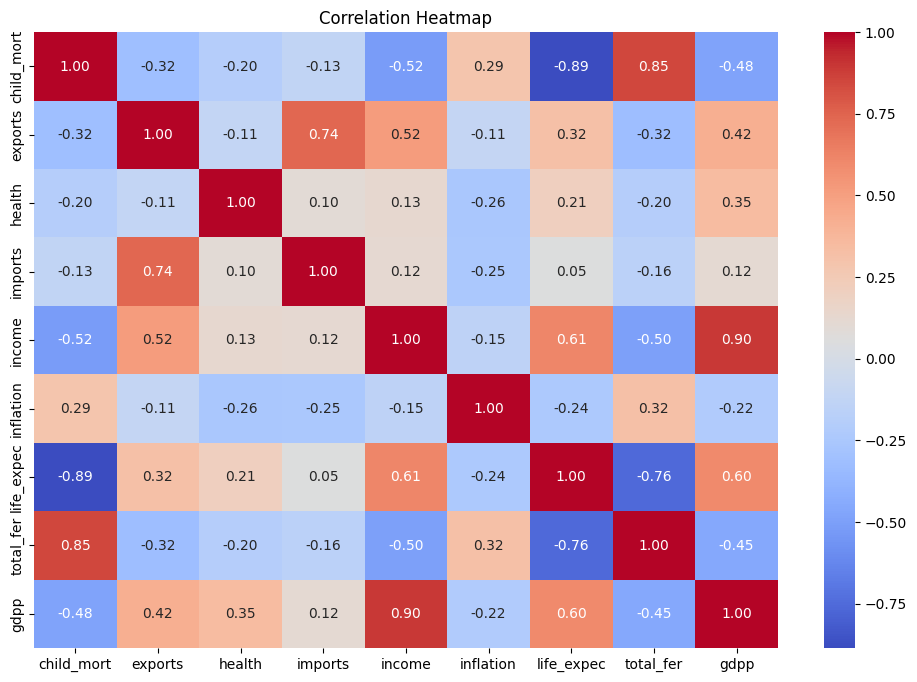

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [19]:
#separating the "country" column as it is just label and keeping it may calculate wrong distances.
countries = df1["country"]

X = df1.drop(columns=["country"])

In [21]:
#Scaling the dataset
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Training KMeans

In [26]:
#creating empty list to store inertia
wcss=[]

#training for different values([2,10])
for k in range(2,11):
  km=KMeans(n_clusters=k,random_state=42,
        n_init=10)
  km.fit(X_scaled)
  wcss.append(km.inertia_)


In [27]:
wcss

[1050.2145582853307,
 831.424435208687,
 700.52053697222,
 620.163371288842,
 558.4696598590399,
 495.8079455215346,
 457.5861478912421,
 427.80367198134667,
 403.2296125136434]

Plotting the Elbow Curve

In [31]:
#mentioned in the asssignment, best_k=3
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels

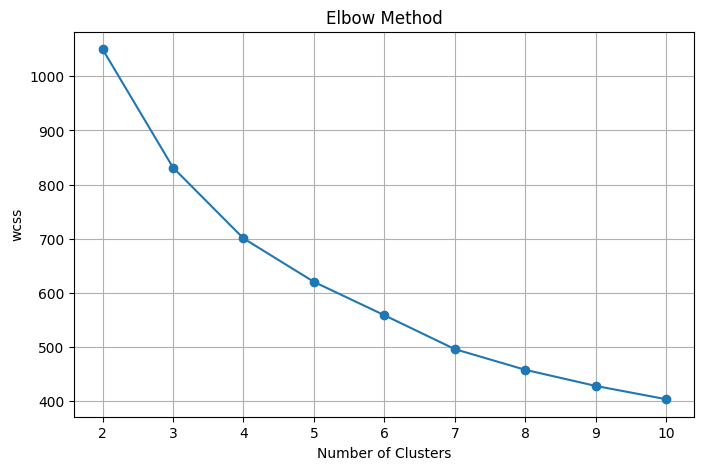

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("wcss")

plt.grid(True)

plt.show()

In [34]:
score = silhouette_score(
    X_scaled,
    labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.28329575683463126


In [65]:
best_k = 5

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels

In [66]:
score = silhouette_score(
    X_scaled,
    labels
)

print("Silhouette Score:", score)

The silhouette score with 5 clusters show slightly better clustering than that with k=3

Training DBSCAN model

In [47]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

In [48]:
df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,137
-1,30


DBSCAN identified 1 dense cluster with 137 countries and 30 countries as noise.

Since it identified only one cluster silloute score cannot be calculated.

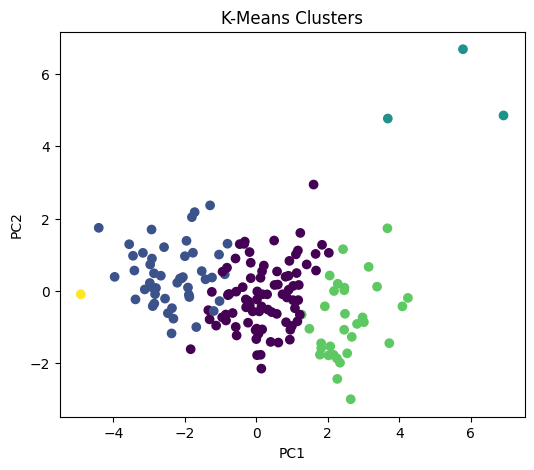

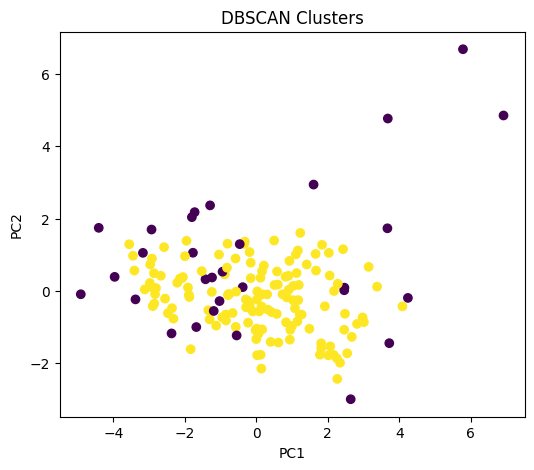

In [69]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="viridis")
plt.title("K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels, cmap="viridis")
plt.title("DBSCAN Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


#plotting for 5 clusters in kMeans.

1. DBSCAN identified one major dense
cluster containing 137 countries.

2. It classified 30 countries (approximately 18%) as noise, indicating potential outliers with unusual socioeconomic characteristics.

3. Unlike K-Means, DBSCAN did not divide the dataset into multiple clusters, suggesting that the dataset does not contain well-separated dense regions under the selected parameters (eps = 1.5, min_samples = 5).

4. DBSCAN proved more effective for outlier detection, whereas K-Means provided a more informative segmentation of countries into distinct groups.

Projecting high-dimensional records into 2D using PCA

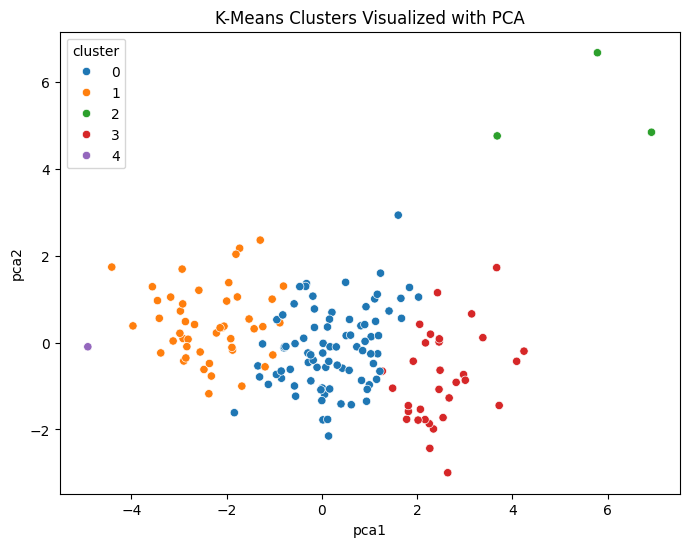

In [68]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['Cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

In [63]:

df["Cluster"] = labels
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
print(cluster_summary)


         child_mort     exports    health     imports        income  \
Cluster                                                               
0         21.614286   40.976060  6.169048   47.518642  12801.071429   
1         90.793617   29.661915  6.462553   43.680851   3870.702128   
2          4.133333  176.000000  6.793333  156.666667  64033.333333   
3          5.181250   46.118750  9.088437   40.584375  44021.875000   
4        130.000000   25.300000  5.070000   17.400000   5150.000000   

          inflation  life_expec  total_fer          gdpp  DBSCAN_Cluster  
Cluster                                                                   
0          7.618857   73.004762   2.277619   6581.809524       -0.059524  
1          9.951809   59.212766   4.974043   1900.255319       -0.319149  
2          2.468000   81.433333   1.380000  57566.666667       -1.000000  
3          2.513844   80.081250   1.788437  42118.750000       -0.187500  
4        104.000000   60.500000   5.840000   2330.00

In [64]:
cluster_summary[
    ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer']
]

,child_mort,income,gdpp,life_expec,total_fer
Cluster,,,,,
0,21.614286,12801.071429,6581.809524,73.004762,2.277619
1,90.793617,3870.702128,1900.255319,59.212766,4.974043
2,4.133333,64033.333333,57566.666667,81.433333,1.380000
3,5.181250,44021.875000,42118.750000,80.081250,1.788437
4,130.000000,5150.000000,2330.000000,60.500000,5.840000


**Observations**


1. Cluster 4(child_mort=130) is the highest-mortality cluster which is followed by cluster 1(child_mort=90)
2. **top-tier economic zones**

cluster 2 with highest income(64033.3) and gdp(57566.6), high import and export, high life expectancy.

Followed by cluster 3

3. **Low development areas**

Cluster 1 and 4 are observed to be the least developed areas with comparatively higher child mortality and lower income, gdp, life expectancy and high fertility rate.

4. Cluster 4 has the highest child mortality (130.0) and extremely high inflation (104.0), suggesting it is an extreme outlier or very vulnerable group rather than a typical cluster.

